Zadanie 5

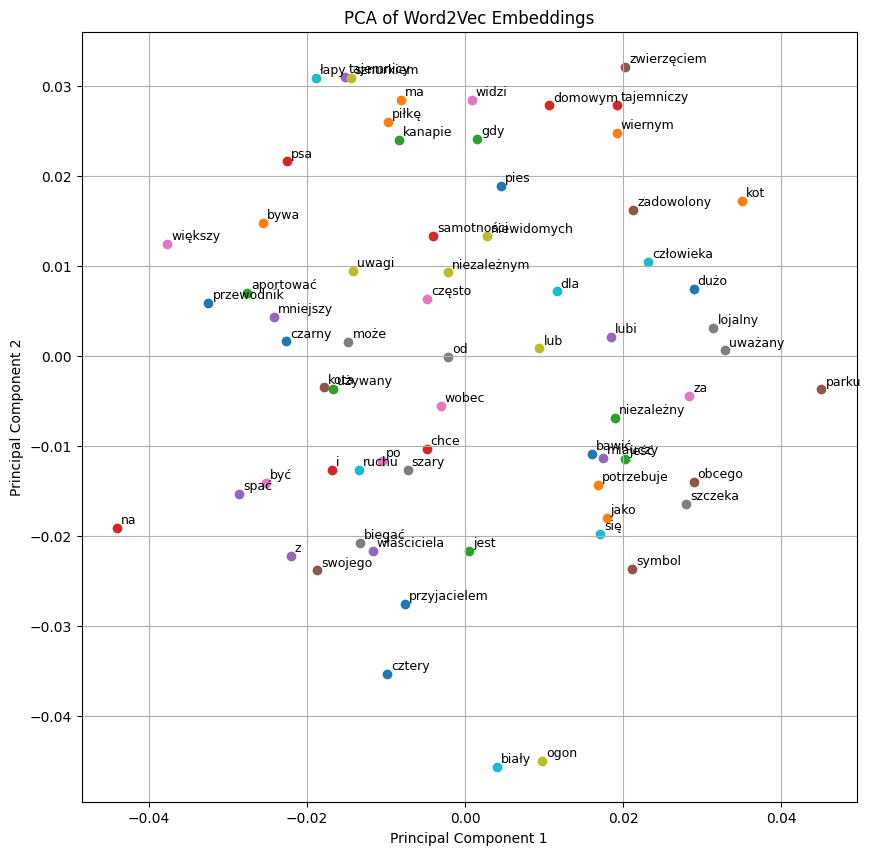

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from gensim.models import Word2Vec

corpus = [
    "Pies jest zwierzęciem domowym.",
    "Kot jest zwierzęciem domowym.",
    "Pies lubi biegać po parku.",
    "Kot lubi spać na kanapie.",
    "Pies jest wiernym przyjacielem człowieka.",
    "Kot jest niezależnym zwierzęciem.",
    "Pies szczeka, gdy widzi obcego.",
    "Kot miauczy, gdy chce jeść.",
    "Pies ma cztery łapy i ogon.",
    "Kot bywa czarny, biały lub szary, ma cztery łapy i ogon.",
    "Pies jest większy od kota.",
    "Kot jest mniejszy od psa.",
    "Pies lubi aportować piłkę.",
    "Kot lubi bawić się sznurkiem.",
    "Pies jest lojalny wobec swojego właściciela.",
    "Kot jest tajemniczy i niezależny.",
    "Pies potrzebuje dużo ruchu i uwagi.",
    "Kot może być zadowolony z samotności.",
    "Pies jest często używany jako pies przewodnik dla niewidomych.",
    "Kot jest często uważany za symbol tajemnicy."
]

tokenized_corpus = [sentence.lower().replace(".", "").replace(",","").split() for sentence in corpus]

model = Word2Vec(sentences=tokenized_corpus, vector_size=50, window=5, min_count=1, workers=4)

words = list(model.wv.index_to_key)
embeddings = [model.wv[word] for word in words]

pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 10))
for i, word in enumerate(words):
    x, y = reduced_embeddings[i]
    plt.scatter(x, y)
    plt.text(x + 0.0005, y + 0.0005, word, fontsize=9)
plt.title("PCA of Word2Vec Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid()
plt.show()

Zadanie 10

c:\Users\joann\Documents\DataScience\LearnIT\CODE\pythonProject\venv2\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Słowa podobne do 'good': [('bad', 0.7558839917182922), ('decent', 0.7244154214859009), ('great', 0.7190605998039246), ('cool', 0.6438995003700256), ('nice', 0.624353289604187)]
Słowa podobne do 'actor': [('actress', 0.7374876737594604), ('performer', 0.6884346604347229), ('role', 0.6788977980613708), ('comedian', 0.6542966961860657), ('performance', 0.6304312348365784)]

Testy analogii:
good : better :: bad : ?
  worse (0.771)
  funnier (0.623)
  harder (0.522)
  stronger (0.520)
  more (0.512)
man : king :: woman : ?
  eyre (0.627)
  queen (0.609)
  jane (0.599)
  austen (0.589)
  modesty (0.558)


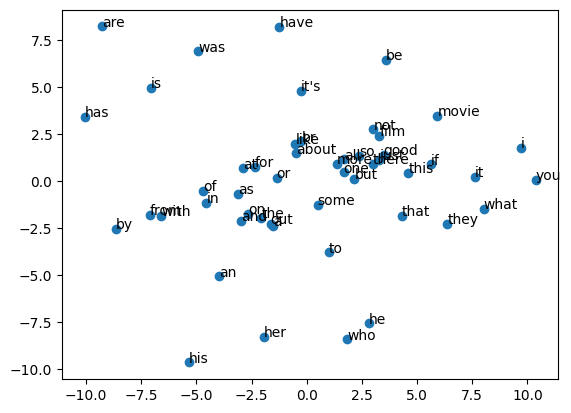

In [13]:
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb


(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

word_index = imdb.get_word_index()
index_word = {v: k for k, v in word_index.items()}

def decode_review(encoded_review):
    return ' '.join([index_word.get(i - 3, '?') for i in encoded_review])
decoded_reviews = [decode_review(review) for review in x_train]
tokenized_corpus = [review.lower().replace('.', '').replace(',', '').replace('!', '').replace('?', '').split() for review in decoded_reviews]

model = Word2Vec(sentences=tokenized_corpus, vector_size=100, window=5, min_count=1, workers=4)

word = 'good'
similar_words = model.wv.most_similar(word, topn=5)
print("Słowa podobne do '" + word + "':", similar_words)

word = 'actor'
similar_words = model.wv.most_similar(word, topn=5)
print("Słowa podobne do '" + word + "':", similar_words)

def analogy(a, b, c):
    try:
        result = model.wv.most_similar(
            positive=[b, c],
            negative=[a],
            topn=5
        )
        print(f"{a} : {b} :: {c} : ?")
        for word, score in result:
            print(f"  {word} ({score:.3f})")
    except KeyError as e:
        print("Brak słowa w słowniku:", e)

print("\nTesty analogii:")
analogy('good', 'better', 'bad')
analogy('man', 'king', 'woman')

words = list(model.wv.index_to_key)[:50]
vectors = [model.wv[word] for word in words]
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1])
for i, word in enumerate(words):
    plt.annotate(word, (vectors_2d[i, 0]+0.005, vectors_2d[i, 1]+0.005))
plt.show()

